IMPORT LIBRARIES

In [54]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from feature_engineering import feature_engineering

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Pipeline
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Save model
import pickle
import sklearn
print(sklearn.__version__)

1.5.1


LOAD DATASET AND CHECK PROBLEM TYPE

In [32]:

df= pd.read_csv("Dataset\\Fraud_Analysis_Dataset.csv")
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [33]:
df.shape

(11142, 10)

In [34]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,11142.0,8.717645e+00,1.606748e+01,1.00,2.0000,6.000,7.0000,95.0
amount,11142.0,2.131915e+05,7.600650e+05,2.39,4946.6175,16761.260,154336.5750,10000000.0
oldbalanceOrg,11142.0,9.241173e+05,2.143004e+06,0.00,427.0000,28169.500,304085.4800,19900000.0
newbalanceOrig,11142.0,8.249576e+05,2.089894e+06,0.00,0.0000,4420.605,111412.6350,13000000.0
oldbalanceDest,11142.0,8.883541e+05,2.601376e+06,0.00,0.0000,0.000,271155.4725,33000000.0
newbalanceDest,11142.0,1.103211e+06,2.982447e+06,0.00,0.0000,0.000,318637.3600,34600000.0
isFraud,11142.0,1.024951e-01,3.033119e-01,0.00,0.0000,0.000,0.0000,1.0


In [37]:
df.duplicated().sum()

0

In [38]:
df[df["amount"] < 0]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud


In [39]:
df.isnull().mean()*100

step              0.0
type              0.0
amount            0.0
nameOrig          0.0
oldbalanceOrg     0.0
newbalanceOrig    0.0
nameDest          0.0
oldbalanceDest    0.0
newbalanceDest    0.0
isFraud           0.0
dtype: float64

In [40]:
df["isFraud"].value_counts()

isFraud
0    10000
1     1142
Name: count, dtype: int64

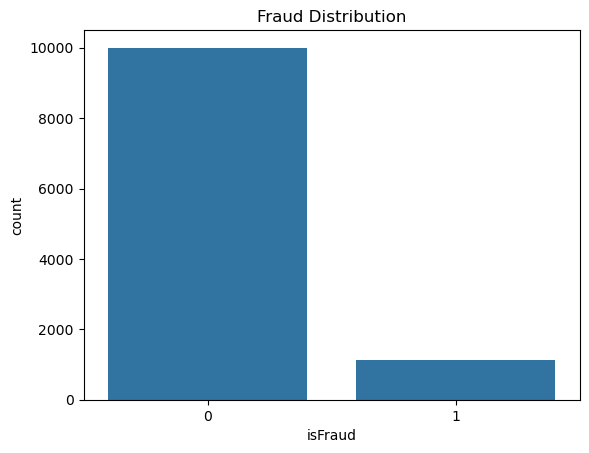

In [41]:
sns.countplot(x="isFraud", data=df)

plt.title("Fraud Distribution")

plt.show()

In [42]:
X = df.drop("isFraud", axis=1)

y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42

)

In [43]:
feature_engineering_transformer = FunctionTransformer(feature_engineering)

In [44]:
temp_df = feature_engineering(X_train)

categorical_features = temp_df.select_dtypes(include="object").columns.tolist()

numerical_features = temp_df.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_features)

print("Numerical:", numerical_features)

Categorical: ['type']
Numerical: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_diff_org', 'balance_diff_dest', 'amount_ratio', 'account_drained', 'hour', 'is_night', 'suspicious_balance', 'high_risk_type']


In [45]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", StandardScaler(), numerical_features),

        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)

    ]

)

In [46]:
models = {

    "LogisticRegression": LogisticRegression(max_iter=1000),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingClassifier()

}

In [47]:
results = {}

for name, model in models.items():

    pipeline = ImbPipeline(

        steps=[

            ("feature_engineering", feature_engineering_transformer),

            ("preprocessing", preprocessor),

            ("smote", SMOTE(random_state=42)),

            ("model", model)

        ]

    )

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)

    f1 = f1_score(y_test, preds)

    results[name] = {

        "Accuracy": acc,

        "F1 Score": f1

    }

    print("\nMODEL:", name)

    print(classification_report(y_test, preds))

  


MODEL: LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2001
           1       0.90      0.98      0.94       228

    accuracy                           0.99      2229
   macro avg       0.95      0.98      0.97      2229
weighted avg       0.99      0.99      0.99      2229


MODEL: RandomForest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229


MODEL: GradientBoosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
w

In [48]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,F1 Score
LogisticRegression,0.986990,0.938947
RandomForest,0.999103,0.995614
GradientBoosting,0.999103,0.995614


In [49]:
best_model_name = results_df["F1 Score"].idxmax()

best_model_name

'RandomForest'

In [50]:
best_model = models[best_model_name]

final_pipeline = ImbPipeline(

    steps=[

        ("feature_engineering", feature_engineering_transformer),

        ("preprocessing", preprocessor),

        ("smote", SMOTE(random_state=42)),

        ("model", best_model)

    ]

)

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function feature_engineering at 0x0000022F91924400>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balance_diff_org',
                                                   'balance_diff_dest',
                                                   'amount_ratio',
                                                   'account_drained', 'hour',
                                                   'is_night',
                                                   'suspicious_balance',
                                                   'high_risk_type']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [51]:
preds = final_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

print("F1 Score:", f1_score(y_test, preds))

print(classification_report(y_test, preds))

Accuracy: 0.9991027366532077
F1 Score: 0.9956140350877193
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       228

    accuracy                           1.00      2229
   macro avg       1.00      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229



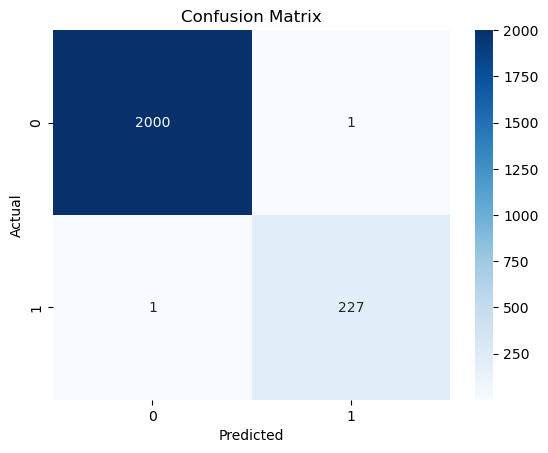

In [52]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [53]:
pickle.dump(

    final_pipeline,

    open("fraud_pipeline_v1.pkl","wb")

)